Device: cpu

===== Model A =====
Epoch 1: Train Acc=0.9471, Val Acc=0.9829
Epoch 2: Train Acc=0.9839, Val Acc=0.9882
Epoch 3: Train Acc=0.9896, Val Acc=0.9891
Epoch 4: Train Acc=0.9918, Val Acc=0.9901
Epoch 5: Train Acc=0.9939, Val Acc=0.9888

===== Model B =====
Epoch 1: Train Acc=0.9363, Val Acc=0.9853
Epoch 2: Train Acc=0.9712, Val Acc=0.9873
Epoch 3: Train Acc=0.9770, Val Acc=0.9843
Epoch 4: Train Acc=0.9798, Val Acc=0.9886
Epoch 5: Train Acc=0.9830, Val Acc=0.9895

===== Model C =====
Epoch 1: Train Acc=0.9621, Val Acc=0.9882
Epoch 2: Train Acc=0.9869, Val Acc=0.9896
Epoch 3: Train Acc=0.9892, Val Acc=0.9920
Epoch 4: Train Acc=0.9921, Val Acc=0.9911
Epoch 5: Train Acc=0.9941, Val Acc=0.9921

===== FINAL RESULTS =====
     Model  Accuracy      Loss
0  Model A    0.9893  0.031159
1  Model B    0.9909  0.030545
2  Model C    0.9924  0.023944


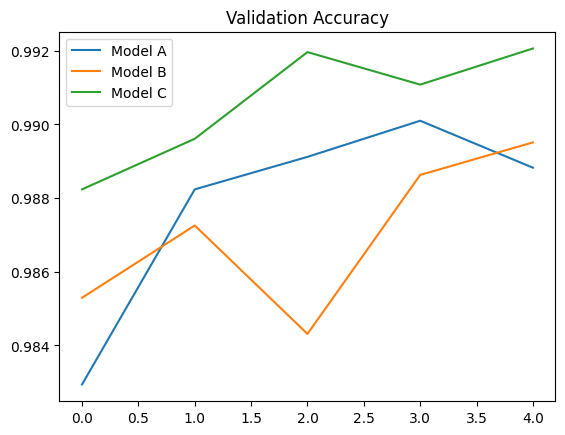

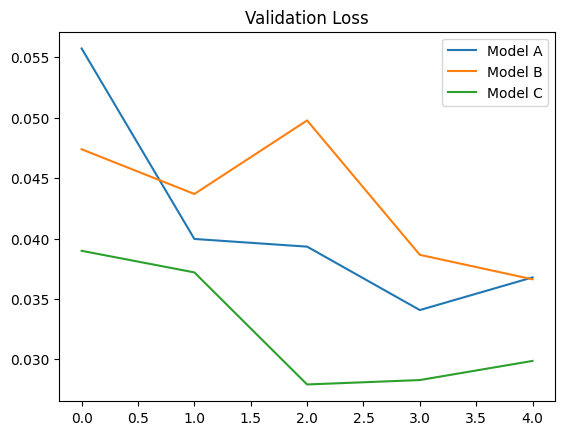

In [4]:
# =========================
# 1. IMPORTS
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 2. DATA PREPROCESSING
# =========================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# =========================
# 3. TRAIN / VAL SPLIT
# =========================
train_size = int(0.83 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

# =========================
# 4. DATALOADERS
# =========================
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# =========================
# 5. MODELS
# =========================

# -------- Model A --------
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# -------- Model B --------
class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# -------- Model C (FIXED) --------
class ModelC(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        # 🔥 fixed dynamically (no shape errors)
        with torch.no_grad():
            x = torch.zeros(1, 1, 28, 28)
            x = self.features(x)
            flat_size = x.view(1, -1).size(1)

        self.classifier = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x


# =========================
# 6. TRAIN FUNCTION
# =========================
def train(model, train_loader, val_loader, optimizer, epochs=5):

    model.to(device)
    criterion = nn.CrossEntropyLoss()

    train_acc_list, val_acc_list = [], []
    train_loss_list, val_loss_list = [], []

    for epoch in range(epochs):

        # ---- TRAIN ----
        model.train()
        correct, total, train_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

        train_acc = correct / total
        train_loss = train_loss / len(train_loader)

        # ---- VALIDATION ----
        model.eval()
        correct, total, val_loss = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, pred = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (pred == labels).sum().item()

        val_acc = correct / total
        val_loss = val_loss / len(val_loader)

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    return train_acc_list, val_acc_list, train_loss_list, val_loss_list


# =========================
# 7. EVALUATION
# =========================
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    correct, total, loss_sum = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item()
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return correct / total, loss_sum / len(loader)


# =========================
# 8. EXPERIMENTS
# =========================
results = []

print("\n===== Model A =====")
model_a = ModelA().to(device)
opt_a = optim.Adam(model_a.parameters(), lr=0.001)
hist_a = train(model_a, train_loader, val_loader, opt_a)
acc_a, loss_a = evaluate(model_a, test_loader)
results.append(["Model A", acc_a, loss_a])

print("\n===== Model B =====")
model_b = ModelB().to(device)
opt_b = optim.Adam(model_b.parameters(), lr=0.001)
hist_b = train(model_b, train_loader, val_loader, opt_b)
acc_b, loss_b = evaluate(model_b, test_loader)
results.append(["Model B", acc_b, loss_b])

print("\n===== Model C =====")
model_c = ModelC().to(device)
opt_c = optim.SGD(model_c.parameters(), lr=0.01, momentum=0.9)
hist_c = train(model_c, train_loader, val_loader, opt_c)
acc_c, loss_c = evaluate(model_c, test_loader)
results.append(["Model C", acc_c, loss_c])


# =========================
# 9. RESULTS TABLE
# =========================
df = pd.DataFrame(results, columns=["Model", "Accuracy", "Loss"])
print("\n===== FINAL RESULTS =====")
print(df)


# =========================
# 10. VISUALIZATION
# =========================

plt.plot(hist_a[1], label="Model A")
plt.plot(hist_b[1], label="Model B")
plt.plot(hist_c[1], label="Model C")
plt.title("Validation Accuracy")
plt.legend()
plt.show()

plt.plot(hist_a[3], label="Model A")
plt.plot(hist_b[3], label="Model B")
plt.plot(hist_c[3], label="Model C")
plt.title("Validation Loss")
plt.legend()
plt.show()

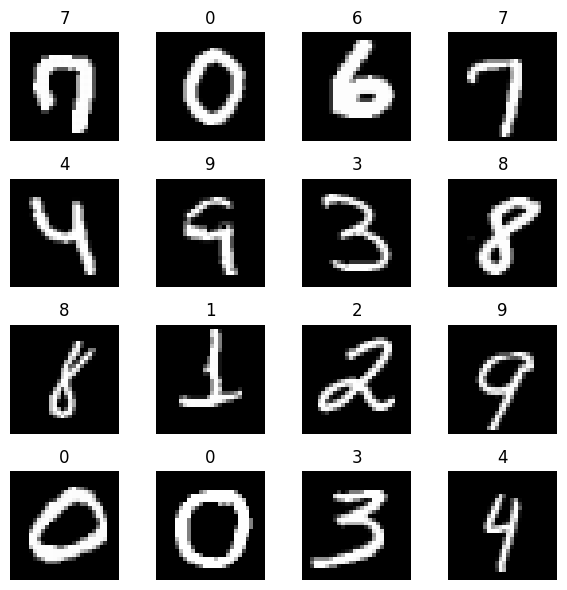

In [5]:
import matplotlib.pyplot as plt

# الحصول على batch من الصور
dataiter = iter(train_loader)
images, labels = next(dataiter)

# تحويل الصور للشكل الطبيعي (للعرض فقط)
images = images * 0.5 + 0.5  # عشان undo normalization

# عرض 16 صورة
plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(str(labels[i].item()))
    plt.axis('off')

plt.tight_layout()
plt.show()
